In [1]:
import numpy as np

In [2]:
mat = np.array([[0, 0, 0, 1],
                [0, 1, 0, 1],
                [0, 1, 0, 1],
                [0, 1, 1, 1]])

In [3]:
n = mat.shape[0]

has_true = mat.any(axis=0)
has_false = ~mat.all(axis=0)
    
S = np.sum(has_true & has_false)

a_n = np.sum(1 / np.arange(1, n))

S, a_n

(np.int64(2), np.float64(1.8333333333333333))

In [4]:
1 / np.arange(1, n)

array([1.        , 0.5       , 0.33333333])

In [5]:
has_true, has_false, has_true & has_false

(array([False,  True,  True,  True]),
 array([ True,  True,  True, False]),
 array([False,  True,  True, False]))

In [6]:
mat = np.array([[0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 1, 1, 1],
                [0, 0, 1, 1, 0, 0, 1, 1],
                [0, 1, 0, 1, 0, 1, 0, 1],
                [0, 0, 1, 1, 1, 1, 0, 0]])
mat

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 1, 1],
       [0, 0, 1, 1, 0, 0, 1, 1],
       [0, 1, 0, 1, 0, 1, 0, 1],
       [0, 0, 1, 1, 1, 1, 0, 0]])

In [7]:
n = mat.shape[0]

pi_sum = 0
for i in range(n):
    for j in range(i + 1, n):
        pi_sum += np.sum(mat[i] != mat[j])

pi = 2 * pi_sum / (n * (n - 1))
pi_sum, pi

(np.int64(38), np.float64(3.8))

In [8]:
n = mat.shape[0]
Wakeley = True

pi_list = []
for i in range(n):
    for j in range(i + 1, n):
        pi_list.append(np.sum(mat[i] != mat[j]))

pi = 2 * np.sum(pi_list) / (n * (n - 1))
result = {'Tajima_pi': pi}

if Wakeley:
    pi2 = 2 * np.sum([(x - pi)**2 for x in pi_list]) / (n * (n - 1))
    result['Wakeley_pi2'] = pi2

result

{'Tajima_pi': np.float64(3.8), 'Wakeley_pi2': np.float64(0.36)}

In [2]:
import sys
sys.path.append('../pysimARG')
from LD_r import LD_r
from LD import LD

In [10]:
for i in range(n-1):
    for j in range(i + 1, n):
        print('------------')
        print(i, j)
        print(LD_r(mat[:, [i, j]]))
        print(LD(mat[:, [i, j]]))

------------
0 1
0.0
{'D': np.float64(0.0), 'D_prime': np.float64(0.0), 'r_square': np.float64(0.0)}
------------
0 2
0.0
{'D': np.float64(0.0), 'D_prime': np.float64(0.0), 'r_square': np.float64(0.0)}
------------
0 3
0.0
{'D': np.float64(0.0), 'D_prime': np.float64(0.0), 'r_square': np.float64(0.0)}
------------
0 4
0.0
{'D': np.float64(0.0), 'D_prime': np.float64(0.0), 'r_square': np.float64(0.0)}
------------
1 2
0.16666666666666666
{'D': np.float64(-0.08000000000000002), 'D_prime': np.float64(1.0000000000000029), 'r_square': np.float64(0.16666666666666574)}
------------
1 3
0.16666666666666674
{'D': np.float64(0.08000000000000002), 'D_prime': np.float64(0.9999999999999972), 'r_square': np.float64(0.16666666666666574)}
------------
1 4
0.0625
{'D': np.float64(-0.04000000000000001), 'D_prime': np.float64(1.0000000000000056), 'r_square': np.float64(0.062499999999999466)}
------------
2 3
0.44444444444444464
{'D': np.float64(0.16000000000000003), 'D_prime': np.float64(0.99999999999999

In [11]:
mat

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 1, 1],
       [0, 0, 1, 1, 0, 0, 1, 1],
       [0, 1, 0, 1, 0, 1, 0, 1],
       [0, 0, 1, 1, 1, 1, 0, 0]])

In [12]:
has_true = mat.any(axis=0)
has_false = ~mat.all(axis=0)
idx_seg = np.where(has_true & has_false)[0]

r_squares = []
if idx_seg.size >= 2:
    for i in range(idx_seg.size - 1):
        for j in range(i + 1, idx_seg.size):
            idx_pair = [idx_seg[i], idx_seg[j]]
            r_sq = LD(mat[:, idx_pair])['r_square']
            r_squares.append(r_sq)

idx_seg, r_squares

(array([1, 2, 3, 4, 5, 6, 7]),
 [np.float64(0.16666666666666574),
  np.float64(0.16666666666666574),
  np.float64(0.062499999999999466),
  np.float64(0.16666666666666574),
  np.float64(0.16666666666666574),
  np.float64(0.16666666666666574),
  np.float64(0.4444444444444429),
  np.float64(0.3749999999999978),
  np.float64(0.027777777777777644),
  np.float64(0.027777777777777644),
  np.float64(0.027777777777777644),
  np.float64(0.16666666666666577),
  np.float64(0.02777777777777772),
  np.float64(0.027777777777777644),
  np.float64(0.02777777777777772),
  np.float64(0.16666666666666574),
  np.float64(0.16666666666666574),
  np.float64(0.3749999999999977),
  np.float64(0.027777777777777644),
  np.float64(0.02777777777777772),
  np.float64(0.4444444444444429)])

In [13]:
len(r_squares)

21

In [14]:
sum(r_squares) * 2 / (7*6)

np.float64(0.1550925925925918)

In [15]:
np.mean(r_squares)

np.float64(0.1550925925925918)

In [16]:
from Kelly_Z import Kelly_Z

In [17]:
Kelly_Z(mat)

np.float64(0.1550925925925918)

In [18]:
mat

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 1, 1],
       [0, 0, 1, 1, 0, 0, 1, 1],
       [0, 1, 0, 1, 0, 1, 0, 1],
       [0, 0, 1, 1, 1, 1, 0, 0]])

In [19]:
mat.astype(bool)

array([[False, False, False, False, False, False, False, False],
       [False, False, False, False, False,  True,  True,  True],
       [False, False,  True,  True, False, False,  True,  True],
       [False,  True, False,  True, False,  True, False,  True],
       [False, False,  True,  True,  True,  True, False, False]])

In [20]:
mat[:, 1]

array([0, 0, 0, 1, 0])

In [21]:
tuple(mat[:, 1])

(np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0))

In [22]:
mat = np.full((5, 10), np.nan)
mat

array([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]])

In [23]:
mat[:, 0] = np.array([0, 1, 1, 1, 1])
mat[:, 1] = np.array([0, 0, 1, 1, 1])
mat[:, 2] = np.array([0, 0, 1, 1, 1])
mat[:, 3] = np.array([1, 1, 0, 0, 0])
mat[:, 4] = np.array([0, 0, 1, 0, 1])
mat[:, 5] = np.array([1, 0, 0, 1, 0])
mat[:, 6] = np.array([0, 1, 1, 1, 1])
mat[:, 7] = np.array([0, 1, 1, 1, 1])
mat[:, 8] = np.array([0, 1, 1, 0, 0])
mat[:, 9] = np.array([1, 0, 1, 1, 1])
mat

array([[0., 0., 0., 1., 0., 1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0., 0., 1., 1., 1., 0.],
       [1., 1., 1., 0., 1., 0., 1., 1., 1., 1.],
       [1., 1., 1., 0., 0., 1., 1., 1., 0., 1.],
       [1., 1., 1., 0., 1., 0., 1., 1., 0., 1.]])

In [24]:
seg_mat = mat.astype(bool)
n = seg_mat.shape[0]
S = seg_mat.shape[1]

B = 0
A = set()
for i in range(S - 1):
    if seg_mat[0, i]:
        col1 = np.logical_not(seg_mat[:, i])
    else:
        col1 = seg_mat[:, i]
    
    if seg_mat[0, i + 1]:
        col2 = np.logical_not(seg_mat[:, i + 1])
    else:
        col2 = seg_mat[:, i + 1]
    
    if np.array_equal(col1, col2):
        B += 1
        A.add(tuple(col1))

B_norm = B / (S - 1)
Q = (B + len(A)) / S
{'B': B_norm, 'Q': Q}

{'B': 0.3333333333333333, 'Q': 0.5}

In [25]:
A

{(np.False_, np.False_, np.True_, np.True_, np.True_),
 (np.False_, np.True_, np.True_, np.True_, np.True_)}

In [26]:
from Wall_BQ import Wall_BQ
Wall_BQ(mat)

{'B': 0.3333333333333333, 'Q': 0.5}

In [27]:
from G4_test import G4_test

In [28]:
mat = np.array([
        [0, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 1],
        [1, 0, 0, 1, 0, 0],
        [1, 0, 1, 1, 0, 1]
    ])
mat

array([[0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 1],
       [1, 0, 0, 1, 0, 0],
       [1, 0, 1, 1, 0, 1]])

In [29]:
n_sites = mat.shape[1]
    
incompatible_intervals = []

for i in range(n_sites - 1):
    for j in range(i + 1, n_sites):
        
        if G4_test(mat[:, [i, j]]):
            incompatible_intervals.append((i, j))

if not incompatible_intervals:
    print(0)

incompatible_intervals.sort(key=lambda x: x[1])

rm_count = 0
last_cut = -1

for start, end in incompatible_intervals:
    if start > last_cut:
        last_cut = end - 1
        rm_count += 1

In [30]:
incompatible_intervals, rm_count

([(0, 2), (2, 3), (0, 5), (3, 5)], 3)

In [31]:
incompatible_intervals = [(0, 2), (0, 4), (3, 7), (5, 7), (7, 9)]

In [32]:
incompatible_intervals.sort(key=lambda x: x[1])

rm_count = 0
last_cut = -1

for start, end in incompatible_intervals:
    if start > last_cut:
        last_cut = end - 1
        rm_count += 1
incompatible_intervals, rm_count

([(0, 2), (0, 4), (3, 7), (5, 7), (7, 9)], 3)

In [4]:
from clonal_genealogy import ClonalTree
from newick_to_tree import newick_to_tree
from ClonalOrigin_seq_sim import ClonalOrigin_seq_sim
from Bio import Phylo

In [5]:
genome_simbac = np.loadtxt("../data/SimBac/genomes_bool.csv", delimiter=",", dtype=bool)

In [6]:
genome_simbac.shape

(10, 100000)

In [7]:
np.random.seed(100)
clonal_tree = ClonalTree(n=10)

# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/SimBac/clonal_frame.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

edge, node_height = newick_to_tree(phylo_tree)
clonal_tree.edge = edge
clonal_tree.node_height = node_height
clonal_tree.height = np.max(node_height)
clonal_tree.length = np.sum(edge[:, 2])

                                                                   _______ 2
                                        __________________________|
                            ___________|                          |_______ 8
                           |           |
                           |           |___________________________________ 1
                           |
                        ___|                         _____________________ 6
                       |   |                       ,|
                       |   |                       ||  ___________________ 3
                       |   |                       ||_|
                       |   |_______________________|  |___________________ 9
  _____________________|                           |
 |                     |                           |         _____________ 5
 |                     |                           |________|
_|                     |                                    |_____________ 7
 |                  

In [8]:
from ClonalOrigin_ARG import ARG
from add_mutation import add_mutation

In [11]:
ARG_sim = ARG(clonal_tree, 0.02, 1000, 300, 1000, "seq")
node_site = add_mutation(ARG_sim, 0.05)
node_site.shape

(157, 1000)

In [12]:
node_site

array([[ True,  True, False, ..., False, False, False],
       [ True,  True, False, ..., False, False, False],
       [ True,  True, False, ..., False, False, False],
       ...,
       [ True,  True, False, ..., False, False, False],
       [ True,  True, False, ..., False, False, False],
       [ True,  True, False, ..., False, False, False]], shape=(157, 1000))

In [13]:
clonal_tree.edge

array([[1.100000e+01, 9.000000e+00, 8.536640e-02],
       [1.100000e+01, 3.000000e+00, 8.536640e-02],
       [1.200000e+01, 1.100000e+01, 2.810870e-01],
       [1.200000e+01, 2.000000e+00, 3.664534e-01],
       [1.300000e+01, 1.000000e+01, 2.170675e-01],
       [1.300000e+01, 4.000000e+00, 2.170675e-01],
       [1.400000e+01, 7.000000e+00, 2.363457e-01],
       [1.400000e+01, 1.300000e+01, 1.927820e-02],
       [1.500000e+01, 8.000000e+00, 1.484719e-01],
       [1.500000e+01, 6.000000e+00, 1.484719e-01],
       [1.600000e+01, 1.500000e+01, 9.942150e-02],
       [1.600000e+01, 1.400000e+01, 1.154770e-02],
       [1.700000e+01, 1.600000e+01, 2.451190e-01],
       [1.700000e+01, 1.200000e+01, 1.265590e-01],
       [1.800000e+01, 5.000000e+00, 5.333798e-01],
       [1.800000e+01, 1.700000e+01, 4.036740e-02],
       [1.900000e+01, 1.800000e+01, 2.390130e-01],
       [1.900000e+01, 1.000000e+00, 7.723928e-01]])

In [14]:
partition1 = np.array([0, 0, 1, 1])
partition2 = np.array([1, 1, 1, 1])

len1 = len(np.unique(partition1))
len2 = len(np.unique(partition2))

len1, len2

(2, 1)

In [15]:
mat = node_site[:10, :]
mat.shape

(10, 1000)

In [16]:
has_true = mat.any(axis=0)
has_false = ~mat.all(axis=0)
idx_seg = np.where(has_true & has_false)[0]

r_squares = []
distances = []
if idx_seg.size >= 2:
    for i in range(idx_seg.size - 1):
        for j in range(i + 1, idx_seg.size):
            dist_ij = idx_seg[j] - idx_seg[i]
            idx_pair = [idx_seg[i], idx_seg[j]]
            r_sq = LD(mat[:, idx_pair])['r_square']
            r_squares.append(r_sq)
            distances.append(dist_ij)

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

In [18]:
df = pd.DataFrame({'x': distances, 'y': r_squares})

# Group by 'x' and calculate the mean of 'y'
mean_y = df.groupby('x')['y'].mean().reset_index()

print(mean_y)

       x         y
0      1  0.515983
1      2  0.325314
2      3  0.297840
3      4  0.154615
4      5  0.421491
..   ...       ...
948  973  0.027778
949  974  0.027778
950  976  0.012346
951  984  0.062500
952  987  0.027778

[953 rows x 2 columns]


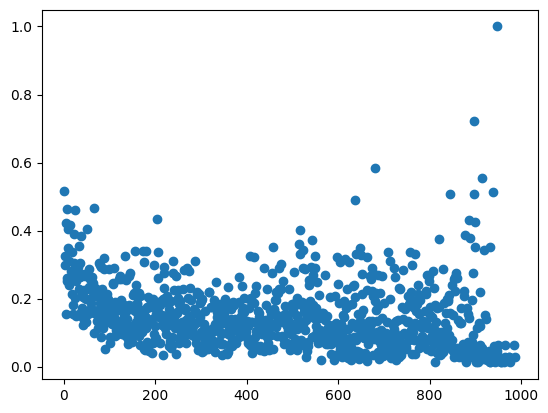

In [19]:
plt.scatter(list(mean_y['x']), list(mean_y['y']))

Fitted parameters:
a = 0.196
b = 0.015
c = 0.137 (Vertical shift)


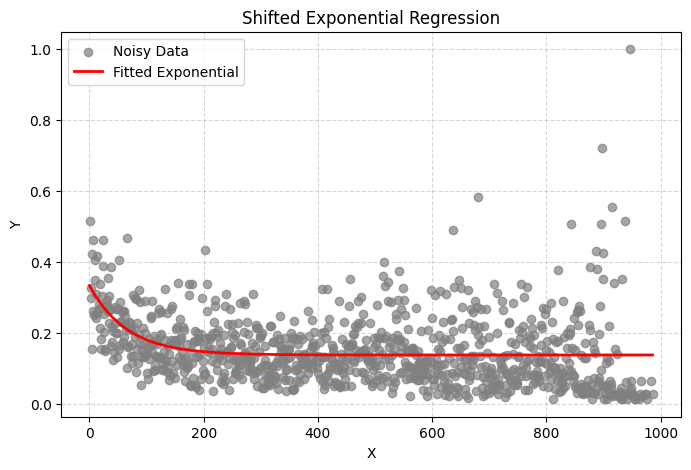

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def shifted_exponential(x, a, b, c):
    """
    a: Amplitude
    b: Growth/decay rate
    c: Vertical shift (asymptote)
    """
    return a * np.exp(-b * x) + c

# np.random.seed(42)
# x_data = np.linspace(0, 4, 50)
# y_true = shifted_exponential(x_data, 2.5, 1.2, 5.0)
# y_data = y_true + 2.0 * np.random.normal(size=x_data.size)
x_data = np.array(mean_y['x'])
x_scaled = x_data - np.min(x_data)
y_data = np.array(mean_y['y'])

initial_guess = [1.0, 1.0, np.min(y_data)] 

popt, pcov = curve_fit(shifted_exponential, x_scaled, y_data, p0=initial_guess)

a_opt, b_opt, c_opt = popt
print(f"Fitted parameters:")
print(f"a = {a_opt:.3f}")
print(f"b = {b_opt:.3f}")
print(f"c = {c_opt:.3f} (Vertical shift)")

plt.figure(figsize=(8, 5))
plt.scatter(x_data, y_data, label='Noisy Data', color='gray', alpha=0.7)

x_fit = np.linspace(min(x_scaled), max(x_scaled), 100)
plt.plot(x_fit, shifted_exponential(x_fit, *popt), label='Fitted Exponential', color='red', linewidth=2)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Shifted Exponential Regression')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [136]:
popt

array([0.18862003, 0.01819379, 0.1463939 ])

In [137]:
tuple(popt)

(np.float64(0.18862002558085095),
 np.float64(0.01819379184988829),
 np.float64(0.14639389659349603))

In [150]:
array1 = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
array1[1:4] = tuple(popt)
array1

array([1.        , 0.18862003, 0.01819379, 0.1463939 , 5.        ])

In [24]:
from ClonalOrigin_seq_sim import ClonalOrigin_seq_sim

s_vec = ClonalOrigin_seq_sim(clonal_tree, 0.02, 0.05, 6000, 300)
s_vec

c:\Users\u2008181\likelihood-free\python\../pysimARG\exp_regression.py:11: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c
c:\Users\u2008181\likelihood-free\python\../pysimARG\exp_regression.py:11: RuntimeWarning: overflow encountered in multiply
  return a * np.exp(-b * x) + c


array([ 1.74000000e+00,  6.42000000e+00,  2.23759698e+05,  7.85291786e+04,
        3.35075027e+04,  1.00626877e+04,  2.20310000e+04,  7.77100000e+03,
        7.24695024e-06,  7.61439381e-05,  9.31939884e-01,  9.31389551e-01,
        1.39555865e-01,  1.19347767e-01,  9.17572188e-02,  9.21673743e-02,
       -9.32000000e+00, -1.40000000e+00,  3.60656230e+03,  3.53716389e+03,
        1.08154789e+03,  9.75461653e+02,  1.14000000e+02,  1.44000000e+02,
       -2.52848616e-03, -3.84721077e-04,  9.78448807e-01,  9.72015358e-01,
        2.93420480e-01,  2.68057613e-01,  3.09278351e-02,  3.95713108e-02,
        3.43113284e-01,  1.34333333e-01,  2.84909524e+02,  2.43400000e+02,
        3.51166222e+03, -7.30786130e-01,  2.03726708e-01,  2.48138958e-01,
        7.50000000e+01,  1.34303871e-01,  2.03579728e-01,  5.59161680e-03,
        1.23069448e-01,  6.00000000e+03])